<a href="https://colab.research.google.com/github/WahyuFairuzD/PCVK_Ganjil_2026/blob/main/Jobsheet5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Wahyu Fairuz Daniswara'
NIM = '244107020225'
N = int(NIM[-3:])

PARAM = {
    'bins': 2 ** ((N % 4) + 3),
    'clip': round(1.0 + (N % 5) * 0.5, 1),
    'tile': (N % 4) + 2,
    'L': 2 ** ((N % 3) + 1),
}

waktu = datetime.datetime.now(
    zoneinfo.ZoneInfo('Asia/Jakarta')
)

print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)

for k, v in PARAM.items():
    print('%-6s :' % k, v)

print(
    'WAKTU :',
    waktu.strftime('%Y-%m-%d %H:%M:%S %Z')
)

print(
    'SISTEM :',
    sys.version.split()[0],
    platform.platform()
)

kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print(
    'TOKEN :',
    hashlib.sha256(kunci.encode()).hexdigest()[:16]
)

In [4]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
from google.colab import drive
import os

In [5]:
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)

    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h[img[y, x]] += 1

    return h

In [ ]:
import cv2 as cv
import matplotlib.pyplot as plt

gray = cv.imread(
    CONTOH + '/bus1.jpg',
    cv.IMREAD_GRAYSCALE
)

print('Ukuran gambar:', gray.shape)
print('Jumlah pixel:', gray.size)

In [ ]:
plt.figure(figsize=(8, 6))

plt.imshow(gray, cmap='gray')
plt.title(NIM + ' - bus1.jpg')
plt.axis('off')

plt.show()

In [16]:
def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)

    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h[img[y, x]] += 1

    return h

In [ ]:
h_manual = histogram_manual(gray)

print('Jumlah pixel       :', gray.size)
print('Jumlah histogram   :', h_manual.sum())

assert h_manual.sum() == gray.size

print('Histogram manual berhasil!')

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(h_manual)

plt.title(NIM + ' - Histogram Manual bus1.jpg')
plt.xlabel('Intensitas Pixel')
plt.ylabel('Jumlah Pixel')

plt.xlim([0, 255])
plt.grid()

plt.show()

In [19]:
h_numpy, edges = np.histogram(
    gray,
    bins=256,
    range=(0, 256)
)

print('Max difference Manual vs NumPy:',
      np.max(np.abs(h_manual - h_numpy)))

Max difference Manual vs NumPy: 0


In [ ]:
h_cv = cv.calcHist(
    [gray],
    [0],
    None,
    [256],
    [0, 256]
).flatten().astype(np.int64)

print('Max difference Manual vs OpenCV:',
      np.max(np.abs(h_manual - h_cv)))

In [ ]:
print('=== PERBANDINGAN HISTOGRAM ===')

print(
    'Manual vs NumPy :',
    np.max(np.abs(h_manual - h_numpy))
)

print(
    'Manual vs OpenCV:',
    np.max(np.abs(h_manual - h_cv))
)

print(
    'NumPy vs OpenCV :',
    np.max(np.abs(h_numpy - h_cv))
)

In [ ]:
# Histogram ternormalisasi
p = h_manual / gray.size

# Cumulative Distribution Function (CDF)
cdf = np.cumsum(p)

print('Jumlah probabilitas :', p.sum())
print('CDF terakhir        :', cdf[-1])

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Normalized Histogram
ax[0].plot(p)

ax[0].set_title(NIM + ' - Normalized Histogram bus1.jpg')
ax[0].set_xlabel('Intensitas Pixel')
ax[0].set_ylabel('p(j)')
ax[0].set_xlim([0, 255])
ax[0].grid()

# CDF
ax[1].plot(cdf)

ax[1].set_title(NIM + ' - CDF bus1.jpg')
ax[1].set_xlabel('Intensitas Pixel')
ax[1].set_ylabel('CDF')
ax[1].set_xlim([0, 255])
ax[1].set_ylim([0, 1])
ax[1].grid()

plt.tight_layout()
plt.show()

In [ ]:
h_16, edges_16 = np.histogram(
    gray,
    bins=PARAM['bins'],
    range=(0, 256)
)

h_256, edges_256 = np.histogram(
    gray,
    bins=256,
    range=(0, 256)
)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# 16 bin
ax[0].bar(
    edges_16[:-1],
    h_16,
    width=np.diff(edges_16),
    align='edge'
)

ax[0].set_title(
    NIM + " - Histogram bus1.jpg - 16 Bins"
)
ax[0].set_xlabel('Intensitas Pixel')
ax[0].set_ylabel('Jumlah Pixel')
ax[0].set_xlim([0, 256])

# 256 bin
ax[1].bar(
    edges_256[:-1],
    h_256,
    width=np.diff(edges_256),
    align='edge'
)

ax[1].set_title(
    NIM + " - Histogram bus1.jpg - 256 Bins"
)
ax[1].set_xlabel('Intensitas Pixel')
ax[1].set_ylabel('Jumlah Pixel')
ax[1].set_xlim([0, 256])

plt.tight_layout()
plt.show()

In [ ]:
# Histogram manual
h = histogram_manual(gray)

# Probabilitas / normalized histogram
p = h / gray.size

# Cumulative Distribution Function
cdf = np.cumsum(p)

# Transformasi Histogram Equalization
L = 256

mapping = np.round((L - 1) * cdf).astype(np.uint8)

# Terapkan mapping ke setiap pixel
gray_he_manual = mapping[gray]

print('Citra asli  :', gray.shape)
print('Citra hasil :', gray_he_manual.shape)
print('Nilai minimum hasil:', gray_he_manual.min())
print('Nilai maksimum hasil:', gray_he_manual.max())

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title(NIM + ' - Citra Asli bus1.jpg')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(gray_he_manual, cmap='gray')
plt.title(NIM + ' - Manual Histogram Equalization')
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
h_before = histogram_manual(gray)
h_after = histogram_manual(gray_he_manual)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(h_before)
plt.title(NIM + ' - Histogram Sebelum HE')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Pixel')
plt.xlim([0, 255])
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(h_after)
plt.title(NIM + ' - Histogram Sesudah HE')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Pixel')
plt.xlim([0, 255])
plt.grid()

plt.tight_layout()
plt.show()

In [30]:
gray_he_cv = cv.equalizeHist(gray)

print('Manual HE dan OpenCV HE berhasil dibuat.')

Manual HE dan OpenCV HE berhasil dibuat.


In [31]:
max_diff = np.max(
    np.abs(
        gray_he_manual.astype(np.int16)
        - gray_he_cv.astype(np.int16)
    )
)

print('Maximum difference:', max_diff)

Maximum difference: 0


In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(gray, cmap='gray')
plt.title(NIM + ' - Asli')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(gray_he_manual, cmap='gray')
plt.title(NIM + ' - Manual HE')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(gray_he_cv, cmap='gray')
plt.title(NIM + ' - OpenCV HE')
plt.axis('off')

plt.tight_layout()
plt.show()

In [33]:
bgr = cv.imread(
    CONTOH + '/bus1.jpg'
)

print('Ukuran citra warna:', bgr.shape)

Ukuran citra warna: (1280, 719, 3)


In [ ]:
kanal = list(cv.split(bgr))

for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])

he_rgb = cv.merge(kanal)

print('Equalisasi kanal B, G, R selesai.')

In [ ]:
ycrcb = cv.cvtColor(
    bgr,
    cv.COLOR_BGR2YCrCb
)

y, cr, cb = cv.split(ycrcb)

he_y = cv.cvtColor(
    cv.merge([
        cv.equalizeHist(y),
        cr,
        cb
    ]),
    cv.COLOR_YCrCb2BGR
)

print('Equalisasi kanal Y selesai.')

In [ ]:
hsv = cv.cvtColor(
    bgr,
    cv.COLOR_BGR2HSV
)

h, sat, v = cv.split(hsv)

he_v = cv.cvtColor(
    cv.merge([
        h,
        sat,
        cv.equalizeHist(v)
    ]),
    cv.COLOR_HSV2BGR
)

print('Equalisasi kanal V selesai.')

In [ ]:
lab = cv.cvtColor(
    bgr,
    cv.COLOR_BGR2LAB
)

l, a, b = cv.split(lab)

he_l = cv.cvtColor(
    cv.merge([
        cv.equalizeHist(l),
        a,
        b
    ]),
    cv.COLOR_LAB2BGR
)

print('Equalisasi kanal L selesai.')

In [ ]:
judul = [
    'Asli',
    'Ekualisasi B, G, R',
    'Kanal Y',
    'Kanal V',
    'Kanal L'
]

citra = [
    bgr,
    he_rgb,
    he_y,
    he_v,
    he_l
]

plt.figure(figsize=(18, 4))

for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 5, i)

    plt.imshow(
        cv.cvtColor(c, cv.COLOR_BGR2RGB)
    )

    plt.title(
        NIM + ' - ' + t,
        fontsize=9
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

In [41]:
def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)

    d = np.abs(h1 - h2)

    # Hue OpenCV berada pada 0-179 dan bersifat melingkar
    d = np.minimum(d, 180 - d)

    return d.mean()

In [ ]:
print('%-22s %16s %16s' %
      ('Cara', 'Geser Hue (der)', 'Rerata terang'))

for t, c in zip(judul, citra):
    print(
        '%-22s %16.2f %16.1f' %
        (
            t,
            geser_hue(bgr, c) * 2,
            cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()
        )
    )

In [43]:
clahe = cv.createCLAHE(
    clipLimit=PARAM['clip'],
    tileGridSize=(PARAM['tile'], PARAM['tile'])
)

# Kita gunakan kanal Y
ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)

y, cr, cb = cv.split(ycrcb)

y_clahe = clahe.apply(y)

clahe_y = cv.cvtColor(
    cv.merge([y_clahe, cr, cb]),
    cv.COLOR_YCrCb2BGR
)

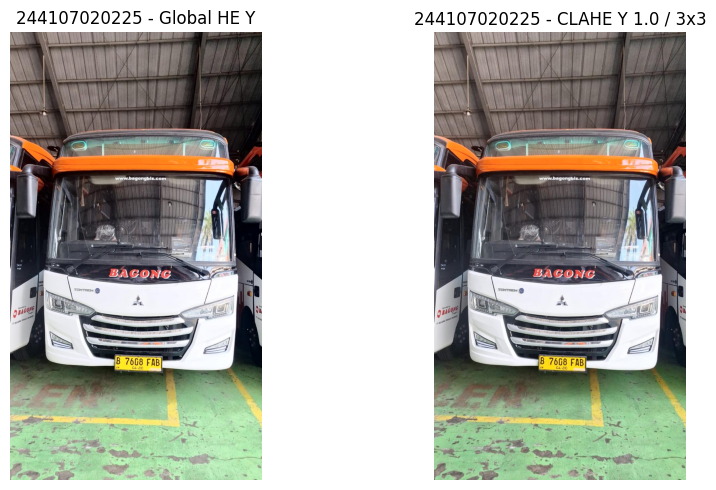

In [44]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(he_y, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Global HE Y')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(clahe_y, cv.COLOR_BGR2RGB))
plt.title(
    NIM + ' - CLAHE Y '
    + str(PARAM['clip'])
    + ' / '
    + str(PARAM['tile']) + 'x'
    + str(PARAM['tile'])
)
plt.axis('off')

plt.tight_layout()
plt.show()

In [45]:
print('%-20s %16s %16s' %
      ('Metode', 'Geser Hue (der)', 'Rerata terang'))

print(
    '%-20s %16.2f %16.1f' %
    (
        'Global HE Y',
        geser_hue(bgr, he_y) * 2,
        cv.cvtColor(he_y, cv.COLOR_BGR2GRAY).mean()
    )
)

print(
    '%-20s %16.2f %16.1f' %
    (
        'CLAHE Y',
        geser_hue(bgr, clahe_y) * 2,
        cv.cvtColor(clahe_y, cv.COLOR_BGR2GRAY).mean()
    )
)

Metode                Geser Hue (der)    Rerata terang
Global HE Y                      0.39            128.1
CLAHE Y                          0.12            127.3


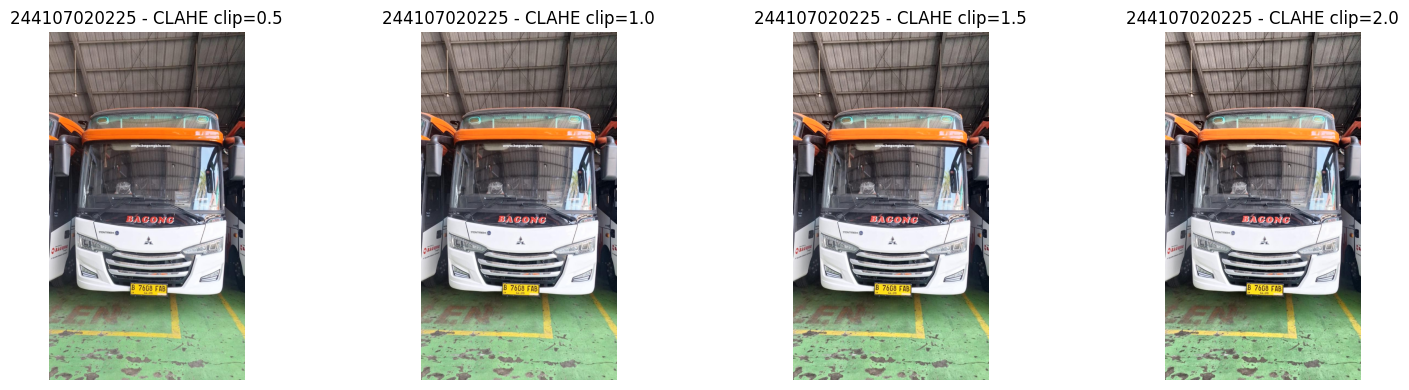

In [46]:
clip_values = [0.5, 1.0, 1.5, 2.0]

plt.figure(figsize=(16, 4))

for i, clip in enumerate(clip_values, 1):

    clahe_test = cv.createCLAHE(
        clipLimit=clip,
        tileGridSize=(PARAM['tile'], PARAM['tile'])
    )

    y_test = clahe_test.apply(y)

    result = cv.cvtColor(
        cv.merge([y_test, cr, cb]),
        cv.COLOR_YCrCb2BGR
    )

    plt.subplot(1, 4, i)

    plt.imshow(
        cv.cvtColor(result, cv.COLOR_BGR2RGB)
    )

    plt.title(
        NIM + ' - CLAHE clip=' + str(clip)
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

In [47]:
def floyd_steinberg(gray, L=2):
    img = gray.astype(np.float32).copy()

    step = 255.0 / (L - 1)

    H, W = img.shape

    for y in range(H):
        for x in range(W):

            lama = img[y, x]

            # Cari level/palet terdekat
            baru = np.round(lama / step) * step

            img[y, x] = baru

            # Hitung error
            error = lama - baru

            # 7/16 ke kanan
            if x + 1 < W:
                img[y, x + 1] += error * 7 / 16

            # 3/16 ke bawah-kiri
            if x > 0 and y + 1 < H:
                img[y + 1, x - 1] += error * 3 / 16

            # 5/16 ke bawah
            if y + 1 < H:
                img[y + 1, x] += error * 5 / 16

            # 1/16 ke bawah-kanan
            if x + 1 < W and y + 1 < H:
                img[y + 1, x + 1] += error * 1 / 16

    return np.clip(img, 0, 255).astype(np.uint8)

In [48]:
dither_direct = floyd_steinberg(
    gray,
    L=PARAM['L']
)

print('Jumlah level:', PARAM['L'])
print('Nilai pixel hasil:', np.unique(dither_direct))

Jumlah level: 2
Nilai pixel hasil: [  0 255]


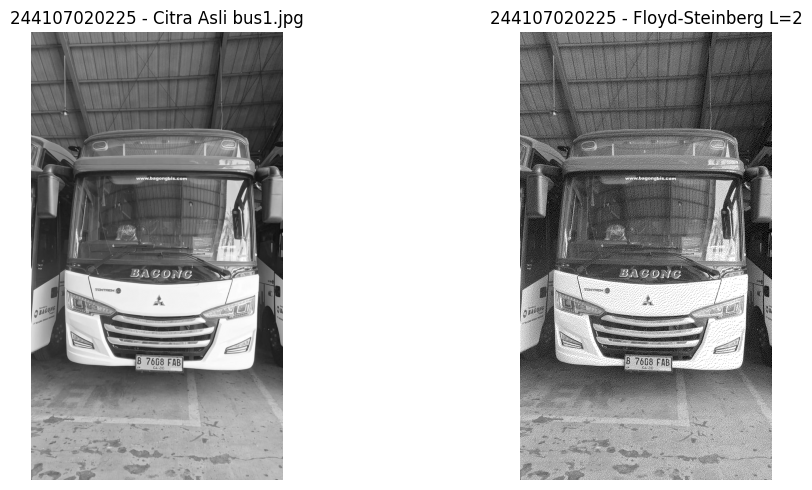

In [49]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.imshow(
    gray,
    cmap='gray'
)

plt.title(
    NIM + ' - Citra Asli bus1.jpg'
)

plt.axis('off')


plt.subplot(1, 2, 2)

plt.imshow(
    dither_direct,
    cmap='gray'
)

plt.title(
    NIM + ' - Floyd-Steinberg L='
    + str(PARAM['L'])
)

plt.axis('off')

plt.tight_layout()
plt.show()

In [50]:
dither_after_he = floyd_steinberg(
    gray_he_manual,
    L=PARAM['L']
)

print('Nilai pixel hasil:',
      np.unique(dither_after_he))

Nilai pixel hasil: [  0 255]


In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)

plt.imshow(
    gray,
    cmap='gray'
)

plt.title(
    NIM + ' - Asli'
)

plt.axis('off')


plt.subplot(1, 3, 2)

plt.imshow(
    dither_direct,
    cmap='gray'
)

plt.title(
    NIM + ' - Dithering Langsung'
)

plt.axis('off')


plt.subplot(1, 3, 3)

plt.imshow(
    dither_after_he,
    cmap='gray'
)

plt.title(
    NIM + ' - HE lalu Dithering'
)

plt.axis('off')


plt.tight_layout()
plt.show()

In [ ]:
h_direct = histogram_manual(dither_direct)
h_after_he = histogram_manual(dither_after_he)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.bar(
    [0, 255],
    [h_direct[0], h_direct[255]],
    width=40
)

plt.title(
    NIM + ' - Histogram Dithering Langsung'
)

plt.xlabel('Intensitas')
plt.ylabel('Jumlah Pixel')


plt.subplot(1, 2, 2)

plt.bar(
    [0, 255],
    [h_after_he[0], h_after_he[255]],
    width=40
)

plt.title(
    NIM + ' - Histogram HE lalu Dithering'
)

plt.xlabel('Intensitas')
plt.ylabel('Jumlah Pixel')


plt.tight_layout()
plt.show()

In this practical work, histogram analysis, histogram equalization, and Floyd–Steinberg dithering were successfully implemented and evaluated using bus1.jpg. The histogram results showed the distribution of pixel intensities, while the normalized histogram and CDF provided a clearer representation of the image’s intensity distribution. The manually calculated histogram also produced the same results as NumPy and OpenCV, confirming the correctness of the implementation.

Histogram Equalization improved the distribution of image intensities and enhanced contrast. Different equalization approaches, including RGB, YCrCb, HSV, LAB, and CLAHE, produced different visual results because each method processes image brightness and color information differently.

Finally, Floyd–Steinberg dithering successfully reduced the grayscale image to the specified number of intensity levels while distributing quantization errors to neighboring pixels. Comparing direct dithering with Histogram Equalization followed by dithering showed that the preprocessing step can affect the resulting visual details and contrast.

Overall, this practical demonstrated how histogram-based techniques can be used to analyze and improve image contrast, while dithering can preserve visual information when reducing the number of available intensity levels.